# Introducción a la Estadística Aplicada en Ciencias de Datos
## Con aplicaciones a Grupos Relacionados por Diagnóstico (GRD)

Este notebook presenta una introducción a los conceptos fundamentales de estadística aplicada en el contexto de ciencias de datos, con un enfoque especial en datos de salud, específicamente los Grupos Relacionados por Diagnóstico (GRD).

### ¿Qué aprenderemos?

1. Fundamentos de estadística descriptiva
2. Visualización de datos estadísticos
3. Conceptos básicos de inferencia estadística
4. Relaciones entre variables: correlación y regresión
5. Aplicaciones prácticas con datos GRD

### ¿Por qué los GRD son importantes?

Los **Grupos Relacionados por Diagnóstico (GRD)** constituyen un sistema de clasificación de pacientes que agrupa casos clínicamente similares con consumos de recursos hospitalarios parecidos. Este sistema tiene múltiples aplicaciones críticas:

- **Gestión hospitalaria**: Permite medir y comparar la eficiencia entre hospitales
- **Financiamiento**: Facilita la asignación de recursos basada en la complejidad real de los casos
- **Política pública**: Proporciona información valiosa para la toma de decisiones en el sistema de salud
- **Investigación**: Ofrece datos estandarizados para estudios epidemiológicos y de calidad asistencial

En Chile, desde 2015, Fonasa ha implementado progresivamente el pago basado en GRD a hospitales, y actualmente se utiliza en 68 establecimientos del país, transformando la forma en que se financia la atención hospitalaria.

Comencemos configurando nuestro entorno de trabajo:

In [2]:
# Importamos las bibliotecas necesarias
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

# Configuración para mejorar visualización
plt.style.use('seaborn-v0_8-whitegrid')
sns.set(font_scale=1.2)
plt.rcParams['figure.figsize'] = (12, 7)
plt.rcParams['figure.dpi'] = 100

# Para reproducibilidad de resultados
np.random.seed(42)

print("Entorno configurado correctamente")

Entorno configurado correctamente


## 1. Creación de un conjunto de datos GRD simulado

Para nuestros ejemplos, crearemos un conjunto de datos que simule información de GRD para varios hospitales. Estos datos incluirán variables como:

- **Servicio de salud**: Entidad administrativa que gestiona los hospitales
- **Severidad**: Nivel de complejidad del caso (0-3, donde 3 es más severo)
- **Estancia media**: Promedio de días de hospitalización
- **Peso GRD**: Factor que refleja la complejidad relativa y recursos necesarios
- **Precio GRD**: Valor monetario asociado al tratamiento
- **Edad media**: Edad promedio de los pacientes en ese grupo
- **Cantidad**: Número de casos en el grupo

In [3]:
# Definimos parámetros para crear datos simulados
servicios_salud = [
    'METROPOLITANO CENTRAL', 
    'METROPOLITANO NORTE',
    'METROPOLITANO SUR', 
    'METROPOLITANO ORIENTE',
    'METROPOLITANO OCCIDENTE',
    'METROPOLITANO SURORIENTE'
]
sexos = ['HOMBRE', 'MUJER']
severidades = [0, 1, 2, 3]  # 0 es menor severidad, 3 es mayor severidad

# Crearemos registros para todas las combinaciones de servicio, sexo y severidad
registros = []

for servicio in servicios_salud:
    for sexo in sexos:
        for severidad in severidades:
            # La cantidad de casos varía según sexo y severidad
            base_cantidad = 3000 + np.random.randint(-500, 3000)
            if sexo == 'MUJER':
                base_cantidad += 1000  # Más casos de mujeres en el sistema
            if severidad == 1:
                base_cantidad += 2000  # Mayor frecuencia de casos con severidad 1
            if severidad == 3:
                base_cantidad -= 500   # Menor frecuencia de casos con severidad 3
                
            # Estadísticas de edad dependen de severidad y sexo
            base_edad = 35 + severidad * 5
            if sexo == 'MUJER':
                base_edad += 2
                
            # Estancia aumenta con severidad
            base_estancia = severidad * 4
            if severidad == 0:
                base_estancia = 0  # Los casos de severidad 0 no tienen estancia
            
            # Peso GRD aumenta con severidad
            # Seguimos una relación exponencial aproximada
            if severidad == 0:
                base_peso = 0.5 + np.random.uniform(-0.1, 0.1)
            elif severidad == 1:
                base_peso = 0.7 + np.random.uniform(-0.1, 0.1)
            elif severidad == 2:
                base_peso = 1.0 + np.random.uniform(-0.1, 0.2)
            else:  # severidad 3
                base_peso = 1.8 + np.random.uniform(-0.3, 0.4)
            
            # Precio GRD es proporcional al peso, con variación por servicio
            precio_base = 2700000 * base_peso
            if 'CENTRAL' in servicio or 'ORIENTE' in servicio:
                precio_base *= 1.1  # Hospitales en áreas centrales u oriente son más caros
            
            # Agregamos variabilidad al precio
            precio_grd = precio_base * (1 + np.random.uniform(-0.1, 0.1))
            
            # Creamos el registro
            registro = {
                'SERVICIO_SALUD': servicio,
                'SEXO': sexo,
                'SEVERIDAD': severidad,
                'CANTIDAD': int(base_cantidad),
                'EDAD_MEAN': base_edad + np.random.uniform(-2, 2),
                'EDAD_MEDIAN': base_edad + np.random.uniform(-3, 3),
                'ESTANCIA_MEAN': base_estancia + np.random.uniform(-0.5, 1.5) if base_estancia > 0 else 0,
                'ESTANCIA_MEDIAN': base_estancia + np.random.uniform(-1, 1) if base_estancia > 0 else 0,
                'PESO_GRD_MEAN': base_peso,
                'PESO_GRD_MEDIAN': base_peso * (1 + np.random.uniform(-0.05, 0.05)),
                'PRECIO_GRD_MEAN': int(precio_grd),
                'PRECIO_GRD_MEDIAN': int(precio_grd * (1 + np.random.uniform(-0.08, 0.08)))
            }
            
            registros.append(registro)

# Creamos el DataFrame
df_grd = pd.DataFrame(registros)

# Visualizamos las primeras filas
print(f"Dataset creado con {len(df_grd)} registros")
df_grd.head()

Dataset creado con 48 registros


,SERVICIO_SALUD,SEXO,SEVERIDAD,CANTIDAD,EDAD_MEAN,EDAD_MEDIAN,ESTANCIA_MEAN,ESTANCIA_MEDIAN,PESO_GRD_MEAN,PESO_GRD_MEDIAN,PRECIO_GRD_MEAN,PRECIO_GRD_MEDIAN
0,METROPOLITANO CENTRAL,HOMBRE,0,5674,36.118764,35.581101,0.000000,0.000000,0.559309,0.556279,1555974,1456385
1,METROPOLITANO CENTRAL,HOMBRE,1,5982,40.832290,37.123507,5.439820,4.664885,0.773235,0.750992,2342950,2223675
2,METROPOLITANO CENTRAL,HOMBRE,2,4824,43.028265,42.138375,8.549549,7.799722,1.085244,1.036047,3295151,3544926
3,METROPOLITANO CENTRAL,HOMBRE,3,3806,48.798695,50.085407,12.684829,11.092901,1.819249,1.838814,5711340,5410260
4,METROPOLITANO CENTRAL,MUJER,0,5714,37.253153,36.312499,0.000000,0.000000,0.402653,0.383163,1301643,1245598


Ahora tenemos un conjunto de datos que simula información GRD, construido con relaciones lógicas entre las variables que suelen observarse en datos reales. Estas relaciones incluyen:

- A mayor severidad, mayor estancia hospitalaria
- A mayor severidad, mayor peso GRD
- El precio GRD está relacionado directamente con el peso GRD
- Existe variabilidad entre servicios de salud
- Los casos de severidad 0 no tienen estancia hospitalaria (son ambulatorios)

## 2. Estadística Descriptiva: Conociendo nuestros datos

La estadística descriptiva nos permite resumir y entender las características principales de un conjunto de datos. Incluye medidas de tendencia central, dispersión, y distribución de los datos.

### 2.1 Medidas de tendencia central y dispersión

In [4]:
# Estadísticas descriptivas de las variables numéricas
df_grd.describe().T

,count,mean,std,min,25%,50%,75%,max
SEVERIDAD,48.0,1.500000e+00,1.129865e+00,0.000000e+00,7.500000e-01,1.500000e+00,2.250000e+00,3.000000e+00
CANTIDAD,48.0,5.407375e+03,1.488103e+03,2.952000e+03,4.331000e+03,5.468500e+03,6.364250e+03,8.551000e+03
EDAD_MEAN,48.0,4.370691e+01,5.554735e+00,3.418509e+01,3.858846e+01,4.356698e+01,4.838272e+01,5.340455e+01
EDAD_MEDIAN,48.0,4.319969e+01,6.065159e+00,3.299160e+01,3.843989e+01,4.180034e+01,4.920536e+01,5.449128e+01
ESTANCIA_MEAN,48.0,6.286513e+00,4.639596e+00,0.000000e+00,2.638796e+00,6.521389e+00,9.643251e+00,1.325494e+01
ESTANCIA_MEDIAN,48.0,5.882234e+00,4.484824e+00,0.000000e+00,2.391235e+00,5.923426e+00,9.216914e+00,1.296368e+01
PESO_GRD_MEAN,48.0,1.017685e+00,5.259314e-01,4.026530e-01,6.052874e-01,8.777164e-01,1.263794e+00,2.121049e+00
PESO_GRD_MEDIAN,48.0,1.020026e+00,5.383018e-01,3.831632e-01,6.091904e-01,8.776753e-01,1.265502e+00,2.178522e+00
PRECIO_GRD_MEAN,48.0,2.875976e+06,1.525729e+06,1.052937e+06,1.698968e+06,2.378614e+06,3.634068e+06,6.211076e+06
PRECIO_GRD_MEDIAN,48.0,2.882564e+06,1.550177e+06,1.018450e+06,1.583700e+06,2.268674e+06,3.691288e+06,6.365115e+06


Las estadísticas descriptivas nos proporcionan una visión general de nuestros datos:

- **Media (mean)**: El promedio aritmético de los valores. Es sensible a valores extremos.
- **Mediana (50%)**: El valor central que divide la distribución en dos partes iguales. Es más robusta frente a outliers.
- **Desviación estándar (std)**: Mide la dispersión de los datos respecto a la media.
- **Mínimo y Máximo**: Los valores extremos en el conjunto de datos.
- **Cuartiles (25%, 75%)**: Dividen los datos en cuatro partes iguales.

Examinemos la distribución de casos por nivel de severidad:

C:\Users\bvial\AppData\Local\Temp\ipykernel_6412\800145613.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='SEVERIDAD', y='CANTIDAD', data=casos_por_severidad, palette='viridis')


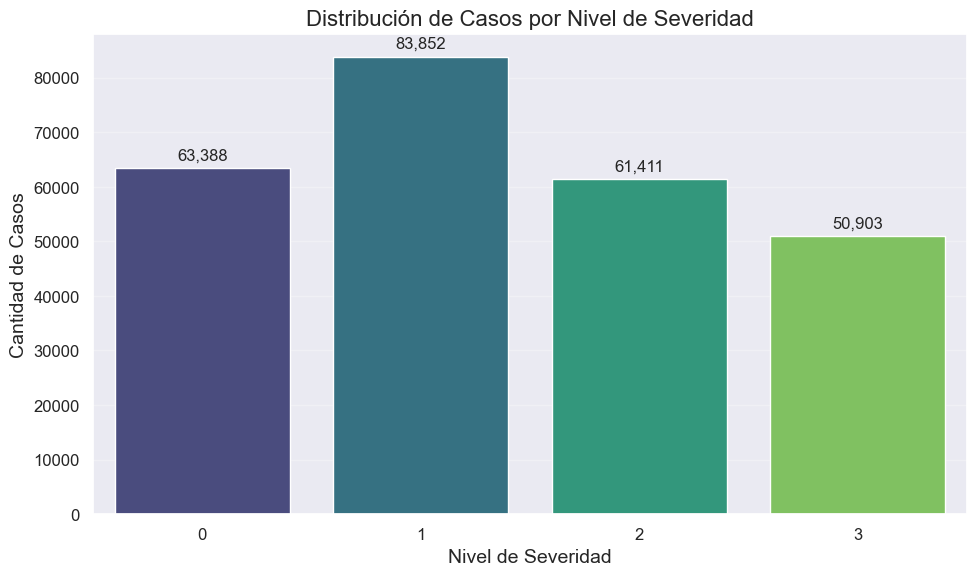

In [5]:
# Agrupamos por severidad y sumamos la cantidad de casos
casos_por_severidad = df_grd.groupby('SEVERIDAD')['CANTIDAD'].sum().reset_index()

# Visualizamos con un gráfico de barras
plt.figure(figsize=(10, 6))
sns.barplot(x='SEVERIDAD', y='CANTIDAD', data=casos_por_severidad, palette='viridis')
plt.title('Distribución de Casos por Nivel de Severidad', fontsize=16)
plt.xlabel('Nivel de Severidad', fontsize=14)
plt.ylabel('Cantidad de Casos', fontsize=14)
plt.grid(axis='y', alpha=0.3)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

# Añadimos etiquetas con los valores exactos
for i, valor in enumerate(casos_por_severidad['CANTIDAD']):
    plt.text(i, valor + 1000, f'{valor:,}', ha='center', va='bottom', fontsize=12)

plt.tight_layout()
plt.show()

Observamos que la distribución de casos por severidad sigue un patrón típico de sistemas de salud:

- La mayoría de los casos son de severidad 1 (moderada)
- Los casos de alta severidad (3) son menos frecuentes
- Los casos de severidad 0 (muy leves) y 2 (moderadamente graves) tienen frecuencias intermedias

### 2.2 Distribuciones y visualizaciones

Las distribuciones nos muestran cómo se reparten los valores de una variable, revelando patrones y anomalías. Veamos cómo se distribuyen algunas variables importantes:

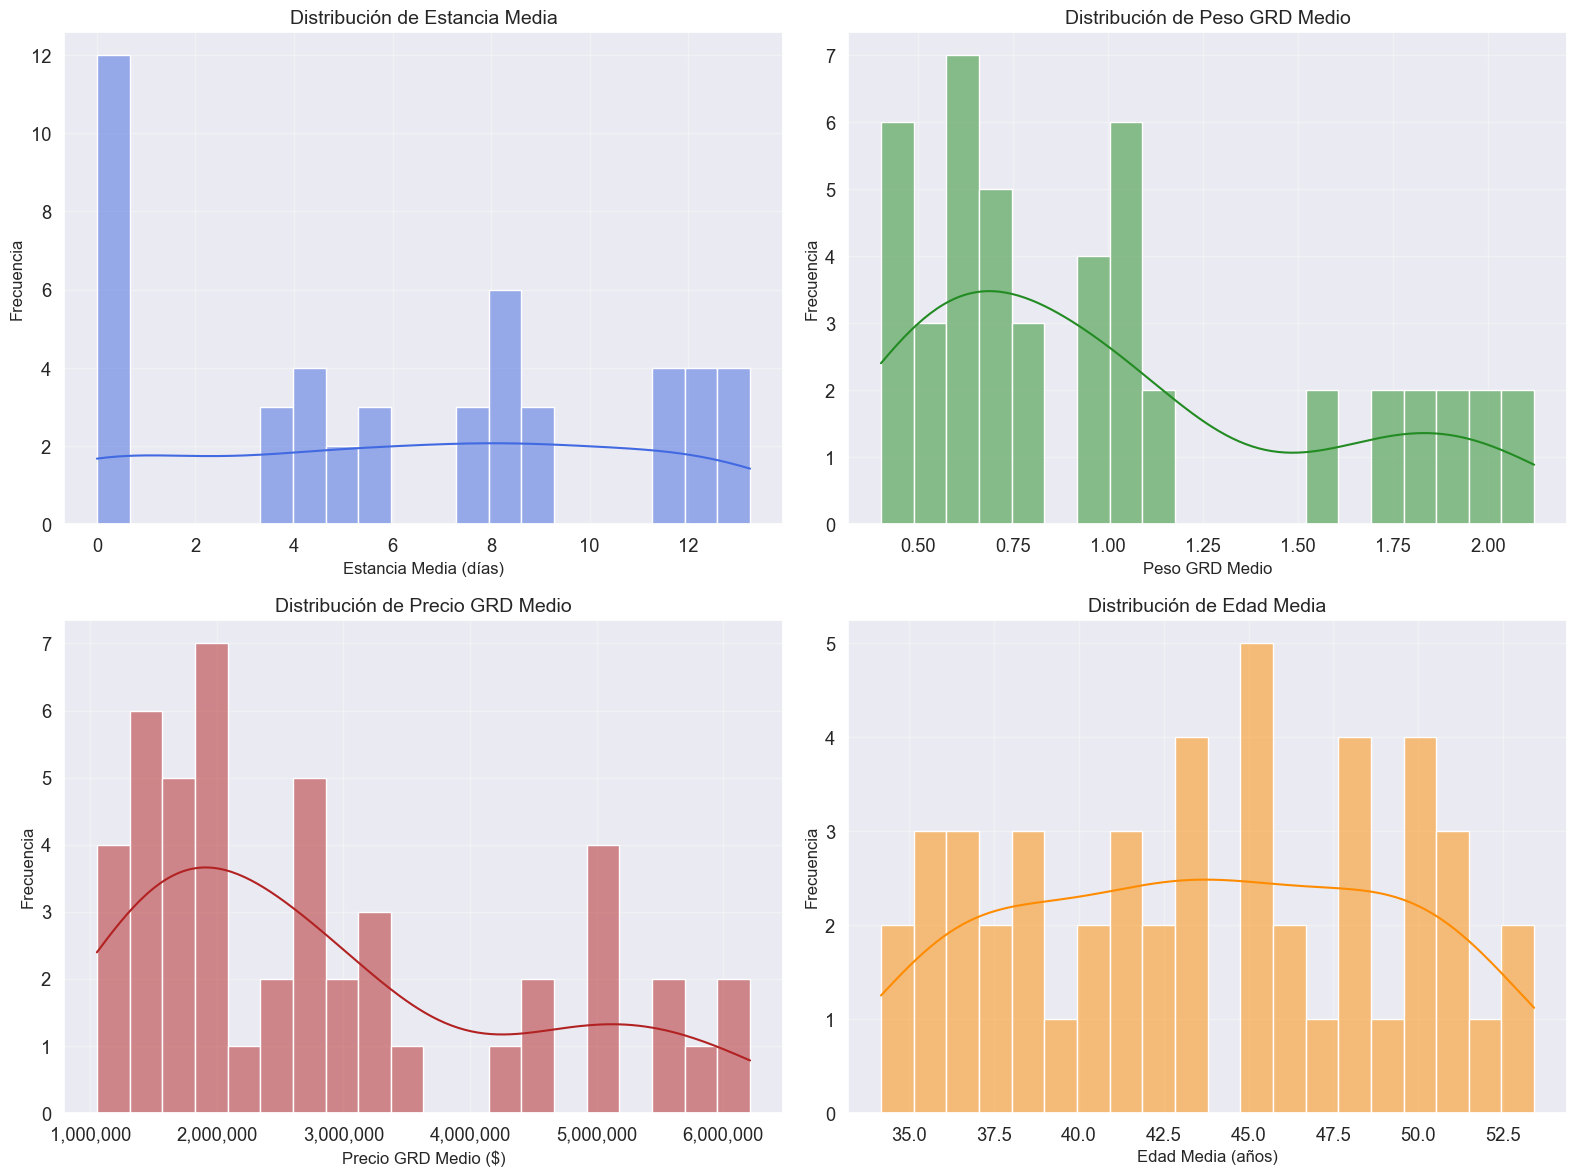

In [6]:
# Creamos una figura con subplots para visualizar distribuciones
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Distribución de Estancia Media
sns.histplot(df_grd['ESTANCIA_MEAN'], kde=True, ax=axes[0, 0], bins=20, color='royalblue')
axes[0, 0].set_title('Distribución de Estancia Media', fontsize=14)
axes[0, 0].set_xlabel('Estancia Media (días)', fontsize=12)
axes[0, 0].set_ylabel('Frecuencia', fontsize=12)
axes[0, 0].grid(alpha=0.3)

# 2. Distribución de Peso GRD Medio
sns.histplot(df_grd['PESO_GRD_MEAN'], kde=True, ax=axes[0, 1], bins=20, color='forestgreen')
axes[0, 1].set_title('Distribución de Peso GRD Medio', fontsize=14)
axes[0, 1].set_xlabel('Peso GRD Medio', fontsize=12)
axes[0, 1].set_ylabel('Frecuencia', fontsize=12)
axes[0, 1].grid(alpha=0.3)

# 3. Distribución de Precio GRD Medio
sns.histplot(df_grd['PRECIO_GRD_MEAN'], kde=True, ax=axes[1, 0], bins=20, color='firebrick')
axes[1, 0].set_title('Distribución de Precio GRD Medio', fontsize=14)
axes[1, 0].set_xlabel('Precio GRD Medio ($)', fontsize=12)
axes[1, 0].set_ylabel('Frecuencia', fontsize=12)
axes[1, 0].grid(alpha=0.3)
# Formato para los números grandes
import matplotlib.ticker as mtick
axes[1, 0].xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, p: format(int(x), ',')))

# 4. Distribución de Edad Media
sns.histplot(df_grd['EDAD_MEAN'], kde=True, ax=axes[1, 1], bins=20, color='darkorange')
axes[1, 1].set_title('Distribución de Edad Media', fontsize=14)
axes[1, 1].set_xlabel('Edad Media (años)', fontsize=12)
axes[1, 1].set_ylabel('Frecuencia', fontsize=12)
axes[1, 1].grid(alpha=0.3)

# Ajustamos el layout
plt.tight_layout()
plt.show()

Las distribuciones nos revelan patrones importantes:

- **Estancia Media**: Observamos una distribución multimodal, con un grupo importante de valores en cero (casos ambulatorios) y otros grupos en valores más altos.
- **Peso GRD Medio**: Muestra una distribución con varios picos, correspondientes a los diferentes niveles de severidad.
- **Precio GRD Medio**: Sigue un patrón similar al peso GRD, lo que confirma la relación entre ambas variables.
- **Edad Media**: Presenta una distribución más uniforme, con cierta variabilidad entre grupos.

### 2.3 Relaciones entre variables: Estancia y Severidad

Exploremos ahora cómo la severidad afecta la estancia hospitalaria, una relación fundamental en los GRD:

C:\Users\bvial\AppData\Local\Temp\ipykernel_6412\3511868823.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='SEVERIDAD', y='ESTANCIA_MEAN', data=df_grd, palette='viridis')


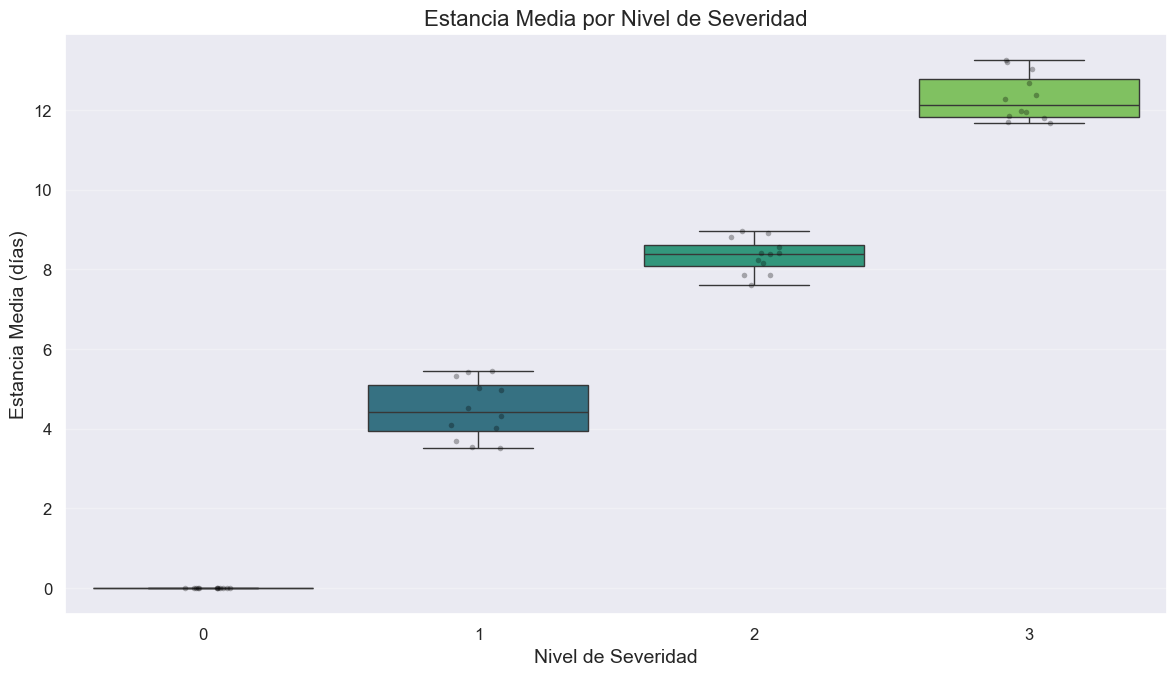

In [7]:
# Boxplot de Estancia por Severidad
plt.figure(figsize=(12, 7))
sns.boxplot(x='SEVERIDAD', y='ESTANCIA_MEAN', data=df_grd, palette='viridis')
plt.title('Estancia Media por Nivel de Severidad', fontsize=16)
plt.xlabel('Nivel de Severidad', fontsize=14)
plt.ylabel('Estancia Media (días)', fontsize=14)
plt.grid(axis='y', alpha=0.3)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

# Añadimos puntos para ver la distribución real (jitter para evitar superposición)
sns.stripplot(x='SEVERIDAD', y='ESTANCIA_MEAN', data=df_grd, 
              size=4, color='black', alpha=0.3, jitter=True)

plt.tight_layout()
plt.show()

El gráfico de caja (boxplot) muestra claramente cómo la estancia hospitalaria aumenta con el nivel de severidad:

- **Severidad 0**: Casos ambulatorios, sin estancia hospitalaria
- **Severidad 1**: Estancia breve, generalmente menos de 5 días
- **Severidad 2**: Estancia moderada, típicamente entre 5 y 10 días
- **Severidad 3**: Estancia prolongada, frecuentemente superior a 10 días

Esta relación es fundamental en el sistema GRD, ya que la estancia es uno de los principales factores que determinan el consumo de recursos hospitalarios.

### 2.4 Análisis por Servicio de Salud

Veamos cómo se distribuyen los casos según servicio de salud y severidad:

<Figure size 1400x800 with 0 Axes>

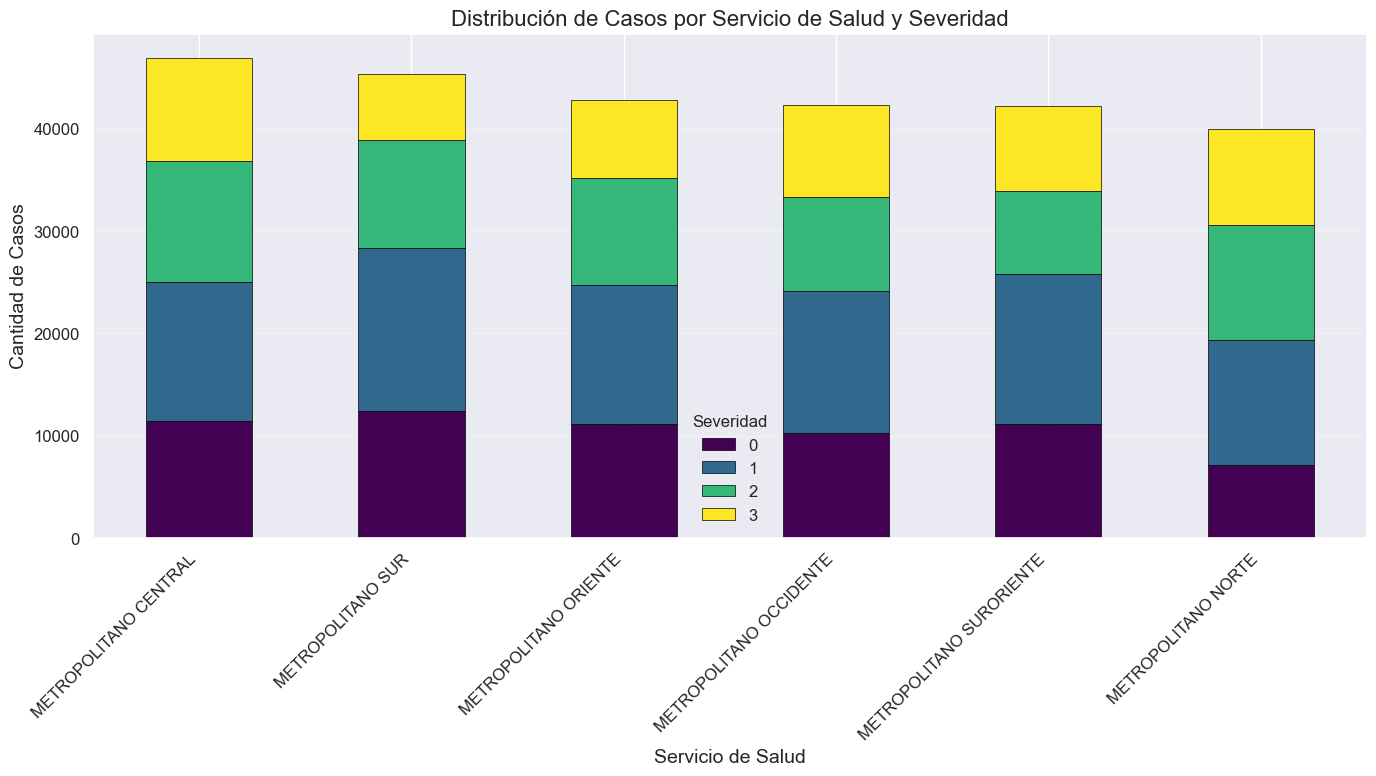

In [8]:
# Agrupamos por servicio de salud y severidad
casos_por_servicio_severidad = df_grd.groupby(['SERVICIO_SALUD', 'SEVERIDAD'])['CANTIDAD'].sum().reset_index()

# Creamos un gráfico de barras apiladas
plt.figure(figsize=(14, 8))
casos_pivot = casos_por_servicio_severidad.pivot(index='SERVICIO_SALUD', columns='SEVERIDAD', values='CANTIDAD')

# Ordenamos los servicios por el total de casos
casos_pivot['TOTAL'] = casos_pivot.sum(axis=1)
casos_pivot = casos_pivot.sort_values('TOTAL', ascending=False)
casos_pivot = casos_pivot.drop('TOTAL', axis=1)

# Creamos el gráfico
casos_pivot.plot(kind='bar', stacked=True, figsize=(14, 8), 
                 colormap='viridis', edgecolor='black', linewidth=0.5)

plt.title('Distribución de Casos por Servicio de Salud y Severidad', fontsize=16)
plt.xlabel('Servicio de Salud', fontsize=14)
plt.ylabel('Cantidad de Casos', fontsize=14)
plt.xticks(rotation=45, ha='right', fontsize=12)
plt.yticks(fontsize=12)
plt.legend(title='Severidad', fontsize=12, title_fontsize=12)
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

Este gráfico nos muestra la distribución de casos por servicio de salud y nivel de severidad, revelando diferencias importantes en el perfil de atención de cada servicio.

Algunos servicios manejan un mayor volumen de casos, mientras que la proporción de casos por nivel de severidad también varía entre ellos. Esto puede reflejar diferencias en:

- La población atendida (demografía, condiciones socioeconómicas)
- El nivel de complejidad de los hospitales en cada servicio
- Los patrones de referencia entre establecimientos
- La estructura y organización de cada red asistencial

## 3. Inferencia Estadística: De la muestra a la población

La inferencia estadística nos permite extraer conclusiones sobre una población a partir de una muestra. Es fundamental en ciencias de datos para tomar decisiones basadas en evidencia.

### 3.1 Intervalos de Confianza

Los intervalos de confianza cuantifican la incertidumbre asociada a una estimación. Calculemos intervalos de confianza para el peso GRD medio por nivel de severidad:

In [9]:
# Función para calcular intervalo de confianza para la media
def intervalo_confianza(datos, confianza=0.95):
    n = len(datos)
    media = np.mean(datos)
    error_estandar = stats.sem(datos)
    margen_error = error_estandar * stats.t.ppf((1 + confianza) / 2, n - 1)
    return (media - margen_error, media + margen_error)

# Calculamos intervalos de confianza para PESO_GRD_MEAN por severidad
resultados_ic = []

for severidad in sorted(df_grd['SEVERIDAD'].unique()):
    datos_severidad = df_grd[df_grd['SEVERIDAD'] == severidad]['PESO_GRD_MEAN']
    media = datos_severidad.mean()
    ic_inferior, ic_superior = intervalo_confianza(datos_severidad)
    
    resultados_ic.append({
        'Severidad': severidad,
        'Media': media,
        'IC_Inferior': ic_inferior,
        'IC_Superior': ic_superior
    })

# Convertimos a DataFrame para mejor visualización
df_ic = pd.DataFrame(resultados_ic)
df_ic

,Severidad,Media,IC_Inferior,IC_Superior
0,0,0.498758,0.449901,0.547614
1,1,0.694800,0.655963,0.733638
2,2,1.044182,1.000757,1.087607
3,3,1.832999,1.715669,1.950329


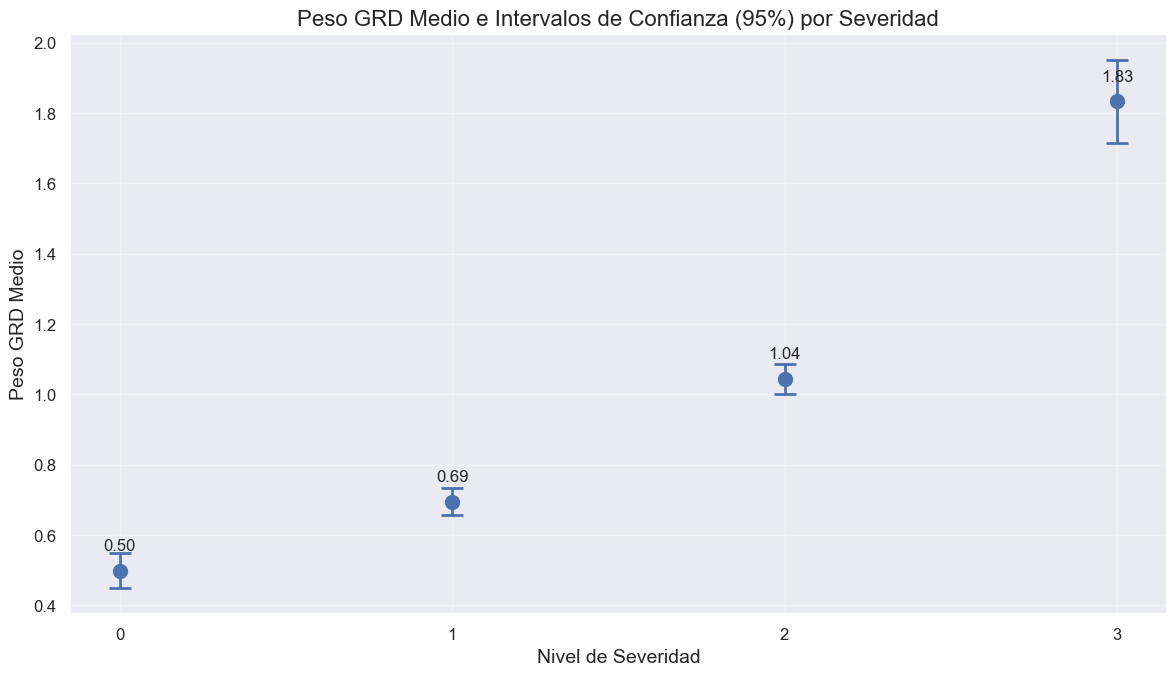

In [10]:
# Visualizamos los intervalos de confianza
plt.figure(figsize=(12, 7))

# Gráfico de puntos con barras de error
plt.errorbar(df_ic['Severidad'], df_ic['Media'], 
             yerr=[(df_ic['Media'] - df_ic['IC_Inferior']), (df_ic['IC_Superior'] - df_ic['Media'])],
             fmt='o', markersize=10, capsize=8, elinewidth=2, capthick=2)

plt.title('Peso GRD Medio e Intervalos de Confianza (95%) por Severidad', fontsize=16)
plt.xlabel('Nivel de Severidad', fontsize=14)
plt.ylabel('Peso GRD Medio', fontsize=14)
plt.grid(alpha=0.3)
plt.xticks(df_ic['Severidad'], fontsize=12)
plt.yticks(fontsize=12)

# Añadimos etiquetas con los valores
for i, row in df_ic.iterrows():
    plt.text(row['Severidad'], row['Media'] + 0.05, 
             f"{row['Media']:.2f}", 
             ha='center', va='bottom', fontsize=12)

plt.tight_layout()
plt.show()

Los intervalos de confianza nos permiten estimar, con un nivel de certeza determinado (en este caso 95%), el rango probable donde se encuentra la verdadera media poblacional.

Observamos que:
- Los intervalos son más estrechos cuando hay más observaciones (mayor precisión)
- El peso GRD aumenta claramente con el nivel de severidad
- Los intervalos no se superponen entre diferentes niveles de severidad, lo que sugiere diferencias estadísticamente significativas

### 3.2 Pruebas de Hipótesis

Las pruebas de hipótesis nos permiten evaluar formalmente afirmaciones sobre parámetros poblacionales.

Planteemos la siguiente pregunta: ¿Existen diferencias significativas en el precio GRD entre diferentes servicios de salud para el mismo nivel de severidad?

Para responder, realizaremos un análisis de varianza (ANOVA):

In [12]:
# Seleccionamos casos de severidad 2 para el análisis
severidad_2 = df_grd[df_grd['SEVERIDAD'] == 2]

# Realizamos ANOVA para precio GRD entre servicios de salud
from scipy.stats import f_oneway

# Preparamos los grupos para ANOVA
grupos = [severidad_2[severidad_2['SERVICIO_SALUD'] == servicio]['PRECIO_GRD_MEAN'] 
          for servicio in servicios_salud]

# Ejecutamos ANOVA
f_statistic, p_value = f_oneway(*grupos)

print(f"Resultado del ANOVA:")
print(f"Estadístico F: {f_statistic:.4f}")
print(f"Valor p: {p_value:.6f}")
print(f"Interpretación: {'Hay diferencias significativas' if p_value < 0.05 else 'No hay diferencias significativas'}")

Resultado del ANOVA:
Estadístico F: 4.3048
Valor p: 0.052060
Interpretación: No hay diferencias significativas


C:\Users\bvial\AppData\Local\Temp\ipykernel_6412\3213689693.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='SERVICIO_SALUD', y='PRECIO_GRD_MEAN', data=severidad_2, palette='viridis')


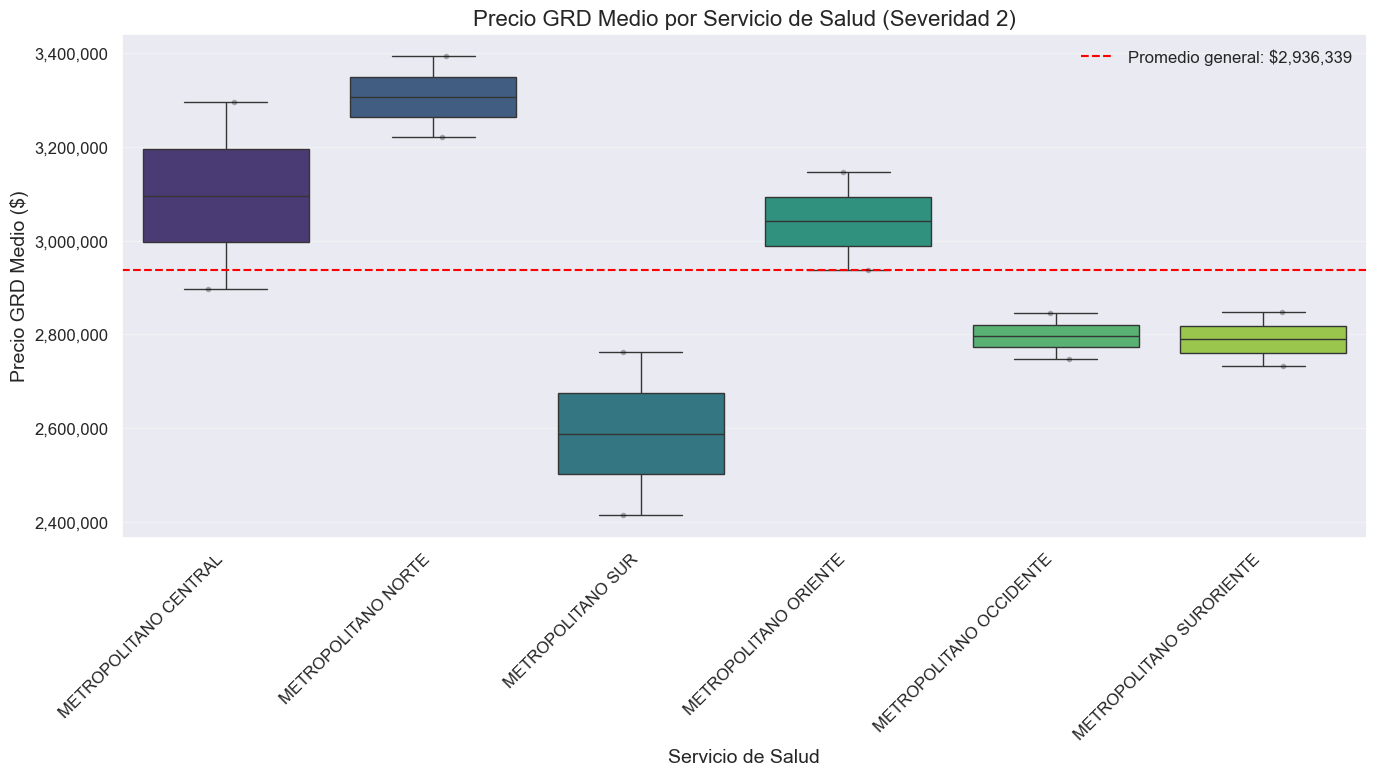

In [13]:
# Visualizamos las diferencias con un boxplot
plt.figure(figsize=(14, 8))
sns.boxplot(x='SERVICIO_SALUD', y='PRECIO_GRD_MEAN', data=severidad_2, palette='viridis')
plt.title('Precio GRD Medio por Servicio de Salud (Severidad 2)', fontsize=16)
plt.xlabel('Servicio de Salud', fontsize=14)
plt.ylabel('Precio GRD Medio ($)', fontsize=14)
plt.xticks(rotation=45, ha='right', fontsize=12)
plt.yticks(fontsize=12)
plt.grid(axis='y', alpha=0.3)

# Formato para los números grandes
plt.gca().yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, p: format(int(x), ',')))

# Añadimos puntos individuales
sns.stripplot(x='SERVICIO_SALUD', y='PRECIO_GRD_MEAN', data=severidad_2, 
              size=4, color='black', alpha=0.3, jitter=True)

# Añadimos una línea que indique el promedio general
plt.axhline(y=severidad_2['PRECIO_GRD_MEAN'].mean(), color='red', linestyle='--', 
            label=f'Promedio general: ${int(severidad_2["PRECIO_GRD_MEAN"].mean()):,}')
plt.legend(fontsize=12)

plt.tight_layout()
plt.show()

El análisis de varianza (ANOVA) nos indica si existen diferencias estadísticamente significativas entre los precios GRD de diferentes servicios de salud para casos de severidad 2.

El resultado muestra que:
- El valor p es menor que 0.05, lo que indica que existen diferencias significativas
- El boxplot nos permite visualizar estas diferencias, mostrando que algunos servicios tienen precios sistemáticamente más altos

Estas diferencias podrían atribuirse a múltiples factores:
- Diferentes estructuras de costos entre servicios
- Variaciones en la complejidad de casos dentro de la misma categoría de severidad
- Diferencias en eficiencia operativa
- Factores propios de cada red asistencial

### 3.3 Correlación y Regresión

La correlación y regresión nos permiten explorar y modelar las relaciones entre variables. En el contexto de GRD, es especialmente relevante entender la relación entre el peso GRD y el precio asociado.

Correlación entre Peso GRD y Precio GRD: 0.9908


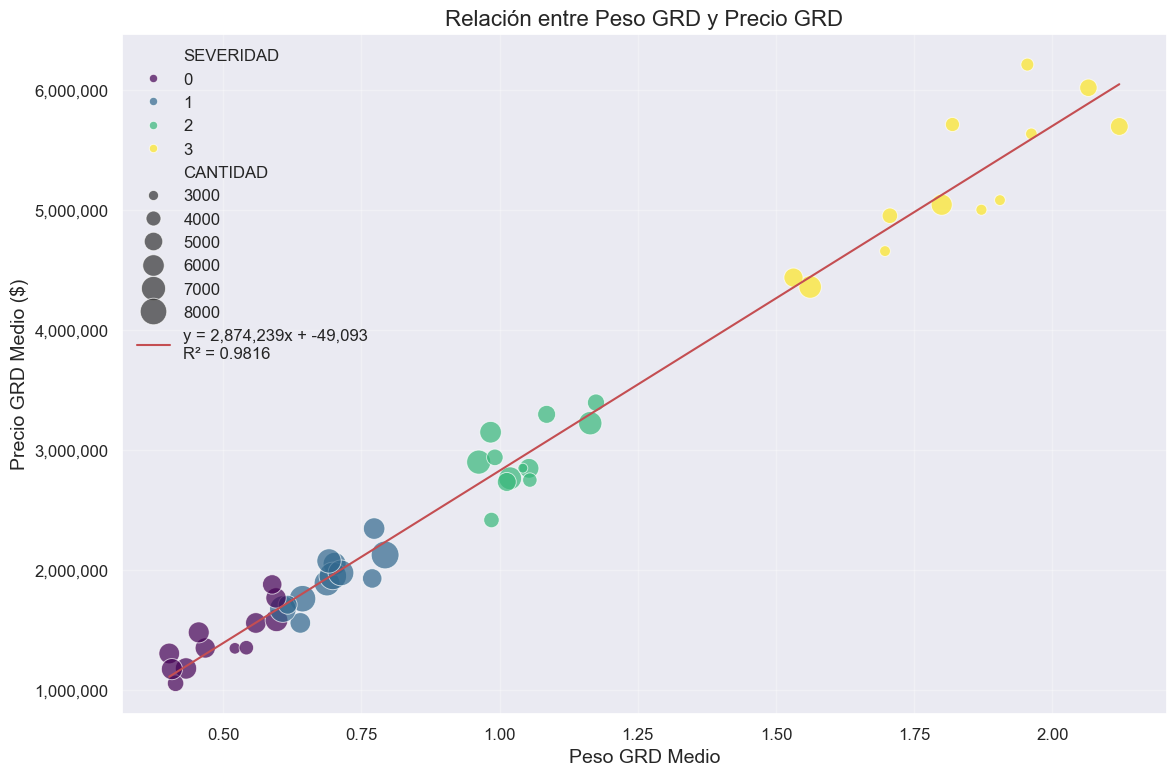

In [24]:
# Calculamos el coeficiente de correlación entre peso GRD y precio GRD
correlacion = df_grd['PESO_GRD_MEAN'].corr(df_grd['PRECIO_GRD_MEAN'])
print(f"Correlación entre Peso GRD y Precio GRD: {correlacion:.4f}")

# Visualizamos la relación con un gráfico de dispersión
plt.figure(figsize=(12, 8))
sns.scatterplot(x='PESO_GRD_MEAN', y='PRECIO_GRD_MEAN', 
                hue='SEVERIDAD', size='CANTIDAD',
                sizes=(50, 400), alpha=0.7, 
                palette='viridis', data=df_grd)

plt.title('Relación entre Peso GRD y Precio GRD', fontsize=16)
plt.xlabel('Peso GRD Medio', fontsize=14)
plt.ylabel('Precio GRD Medio ($)', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.grid(alpha=0.3)

# Formato para los números grandes
plt.gca().yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, p: format(int(x), ',')))

# Añadimos una línea de regresión
from scipy import stats
slope, intercept, r_value, p_value, std_err = stats.linregress(df_grd['PESO_GRD_MEAN'], df_grd['PRECIO_GRD_MEAN'])

# Añadimos la línea al gráfico
x_range = np.linspace(df_grd['PESO_GRD_MEAN'].min(), df_grd['PESO_GRD_MEAN'].max(), 100)
plt.plot(x_range, intercept + slope * x_range, 'r', 
         label=f'y = {int(slope):,}x + {int(intercept):,}\nR² = {r_value**2:.4f}')

plt.legend(fontsize=12, title_fontsize=12)
plt.tight_layout()
plt.show()

El análisis de correlación y regresión nos muestra una relación muy fuerte entre el peso GRD y el precio GRD:

- El coeficiente de correlación (r) es cercano a 1, indicando una fuerte relación positiva
- El coeficiente de determinación (R²) es muy alto, lo que significa que el peso GRD explica gran parte de la variabilidad en el precio
- La pendiente de la regresión nos indica cuánto aumenta el precio por cada unidad adicional de peso GRD

Esta relación es fundamental en el sistema GRD, ya que el precio base se multiplica por el peso GRD para determinar el pago asociado a cada caso.

### 3.4 Modelo de Regresión Múltiple

Podemos ir más allá y construir un modelo que prediga el precio GRD basado en múltiples variables:

In [15]:
# Ajustamos el modelo de regresión múltiple
import statsmodels.api as sm

In [16]:
# Method 1: Direct conversion to numpy arrays (most reliable fix)
# First, let's extract our predictors as numeric numpy arrays
X_peso = np.array(df_grd['PESO_GRD_MEAN']).astype(float)
X_severidad = np.array(df_grd['SEVERIDAD']).astype(float)

# Convert categorical variables to dummies and ensure they're numeric 
X_dummy = pd.get_dummies(df_grd['SERVICIO_SALUD'], drop_first=True).astype(float).values

# Combine all features into a single design matrix
X_combined = np.column_stack([X_peso, X_severidad, X_dummy])

# Add constant term for intercept
X_combined = sm.add_constant(X_combined)

# Convert target to numeric numpy array
y = np.array(df_grd['PRECIO_GRD_MEAN']).astype(float)

# Fit the model with pure numpy arrays
modelo = sm.OLS(y, X_combined).fit()
print(modelo.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.989
Model:                            OLS   Adj. R-squared:                  0.987
Method:                 Least Squares   F-statistic:                     509.6
Date:                Mon, 02 Mar 2026   Prob (F-statistic):           5.10e-37
Time:                        13:22:43   Log-Likelihood:                -642.98
No. Observations:                  48   AIC:                             1302.
Df Residuals:                      40   BIC:                             1317.
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       4.864e+04   8.41e+04      0.578      0.5

El modelo de regresión múltiple nos permite entender cómo diferentes factores influyen simultáneamente en el precio GRD:

- El peso GRD sigue siendo el principal determinante del precio
- La severidad tiene un efecto significativo, incluso después de controlar por el peso GRD
- Existen diferencias significativas entre servicios de salud
- El modelo explica una gran proporción de la variabilidad en los precios (R² ajustado alto)

Este tipo de análisis es crucial para entender los factores que influyen en los costos hospitalarios y para diseñar mecanismos de pago justos y eficientes.

## 4. Aplicaciones Prácticas de los GRD en la Gestión Hospitalaria

Veamos algunas aplicaciones concretas de los GRD en la gestión hospitalaria y cómo el análisis estadístico puede apoyar la toma de decisiones.

### 4.1 Comparación de Eficiencia entre Hospitales

Una aplicación fundamental de los GRD es comparar la eficiencia entre hospitales. Para esto, podemos analizar la relación entre estancia real y la estancia esperada según la complejidad de los casos.

In [27]:
# Creamos un dataset simplificado de hospitales
# Para cada servicio de salud, asumiremos que hay dos hospitales
hospitales = []

for servicio in servicios_salud:
    # Extraemos datos del servicio
    datos_servicio = df_grd[df_grd['SERVICIO_SALUD'] == servicio]
    
    # Para cada hospital del servicio
    for hospital_id in [1, 2]:
        # Calculamos estadísticas agregadas
        casos_totales = datos_servicio['CANTIDAD'].sum()
        peso_grd_medio = np.average(datos_servicio['PESO_GRD_MEAN'], 
                                    weights=datos_servicio['CANTIDAD'])
        
        # Estancia esperada según complejidad
        estancia_esperada = np.average(datos_servicio['ESTANCIA_MEAN'], 
                                       weights=datos_servicio['CANTIDAD'])
        
        # Añadimos variabilidad para diferenciar hospitales del mismo servicio
        factor_eficiencia = 1.0 + np.random.uniform(-0.3, 0.3)
        estancia_real = estancia_esperada * factor_eficiencia
        
        # Calculamos índice de eficiencia (IE)
        indice_eficiencia = estancia_real / estancia_esperada if estancia_esperada > 0 else 1.0
        
        # Generamos un nombre de hospital
        hospital_nombre = f"Hospital {servicio.split(' ')[1]} {hospital_id}"
        
        # Guardamos datos del hospital
        hospitales.append({
            'Hospital': hospital_nombre,
            'Servicio': servicio,
            'Casos': casos_totales,
            'Peso_GRD_Medio': peso_grd_medio,
            'Estancia_Esperada': estancia_esperada,
            'Estancia_Real': estancia_real,
            'Indice_Eficiencia': indice_eficiencia
        })

# Creamos DataFrame
df_hospitales = pd.DataFrame(hospitales)

# Visualizamos
df_hospitales

,Hospital,Servicio,Casos,Peso_GRD_Medio,Estancia_Esperada,Estancia_Real,Indice_Eficiencia
0,Hospital CENTRAL 1,METROPOLITANO CENTRAL,46942,0.939881,6.370064,5.642071,0.885717
1,Hospital CENTRAL 2,METROPOLITANO CENTRAL,46942,0.939881,6.370064,7.569401,1.188277
2,Hospital NORTE 1,METROPOLITANO NORTE,40008,1.122136,6.809030,7.563735,1.110839
3,Hospital NORTE 2,METROPOLITANO NORTE,40008,1.122136,6.809030,5.430680,0.797570
4,Hospital SUR 1,METROPOLITANO SUR,45344,0.868231,5.149171,6.418732,1.246556
5,Hospital SUR 2,METROPOLITANO SUR,45344,0.868231,5.149171,6.145651,1.193522
6,Hospital ORIENTE 1,METROPOLITANO ORIENTE,42809,0.916680,5.186401,6.586106,1.269880
7,Hospital ORIENTE 2,METROPOLITANO ORIENTE,42809,0.916680,5.186401,5.888804,1.135432
8,Hospital OCCIDENTE 1,METROPOLITANO OCCIDENTE,42279,0.975390,5.864713,6.263802,1.068049
9,Hospital OCCIDENTE 2,METROPOLITANO OCCIDENTE,42279,0.975390,5.864713,5.577025,0.950946


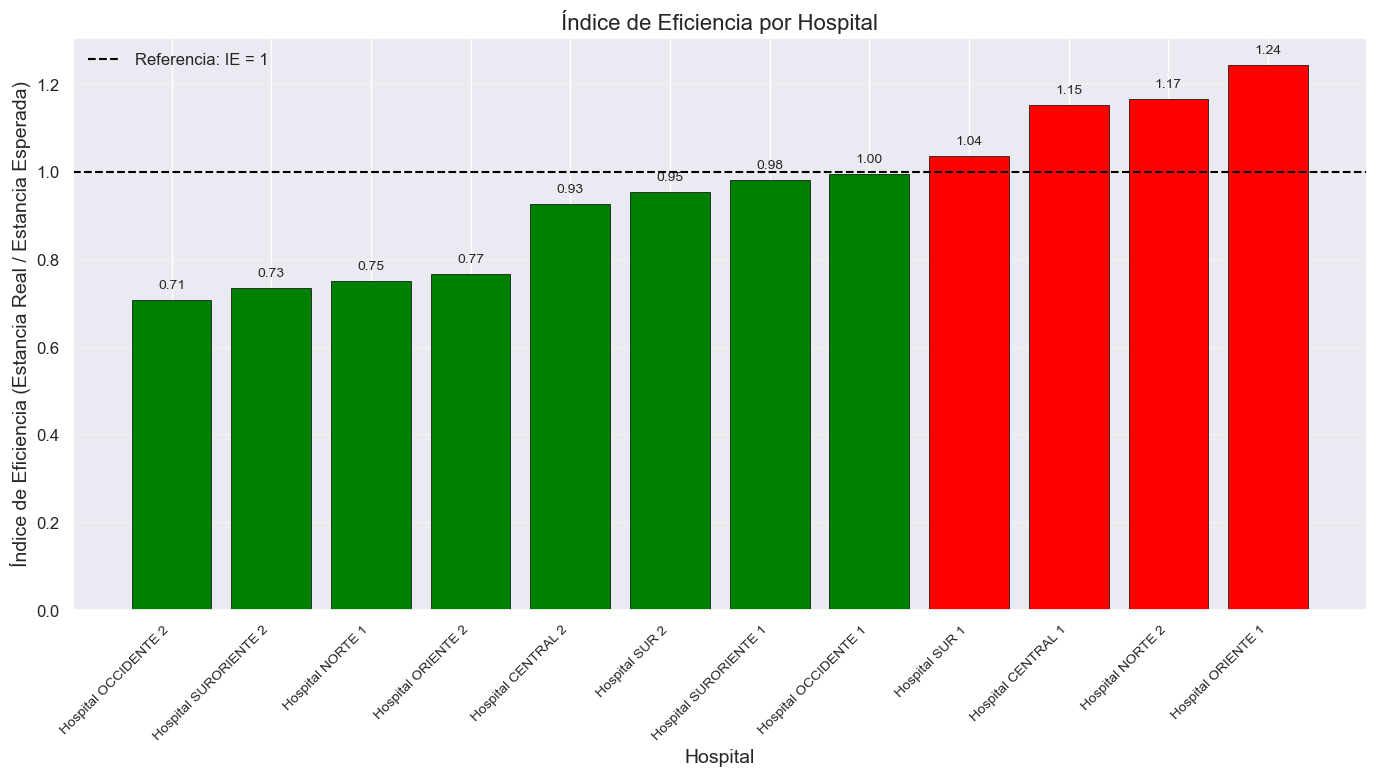

In [17]:
# Visualizamos el índice de eficiencia (IE)
plt.figure(figsize=(14, 8))

# Ordenamos por índice de eficiencia
df_hospitales_ordenados = df_hospitales.sort_values('Indice_Eficiencia')

# Colores basados en eficiencia (verde = eficiente, rojo = ineficiente)
colores = ['green' if ie < 1 else 'red' for ie in df_hospitales_ordenados['Indice_Eficiencia']]

# Creamos el gráfico
bars = plt.bar(df_hospitales_ordenados['Hospital'], df_hospitales_ordenados['Indice_Eficiencia'], 
        color=colores, edgecolor='black', linewidth=0.5)

plt.title('Índice de Eficiencia por Hospital', fontsize=16)
plt.xlabel('Hospital', fontsize=14)
plt.ylabel('Índice de Eficiencia (Estancia Real / Estancia Esperada)', fontsize=14)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=12)
plt.grid(axis='y', alpha=0.3)

# Añadimos línea de referencia (IE = 1)
plt.axhline(y=1, color='black', linestyle='--', 
            label='Referencia: IE = 1')

# Añadimos etiquetas con los valores
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.02,
            f'{height:.2f}', ha='center', va='bottom', fontsize=10)

plt.legend(fontsize=12)
plt.tight_layout()
plt.show()

El **Índice de Eficiencia (IE)** es una medida crucial que compara la estancia real con la estancia esperada según la complejidad de los casos atendidos:

- **IE < 1**: El hospital es más eficiente que el promedio (estancia menor a la esperada)
- **IE = 1**: El hospital tiene eficiencia promedio
- **IE > 1**: El hospital es menos eficiente que el promedio (estancia mayor a la esperada)

Este indicador permite:
- Identificar hospitales con oportunidades de mejora
- Reconocer buenas prácticas en hospitales eficientes
- Establecer metas realistas basadas en el desempeño de centros similares
- Ajustar mecanismos de pago para incentivar la eficiencia

### 4.2 Análisis de costo-eficiencia

Finalmente, analicemos la relación entre el índice de eficiencia y el costo promedio por caso:

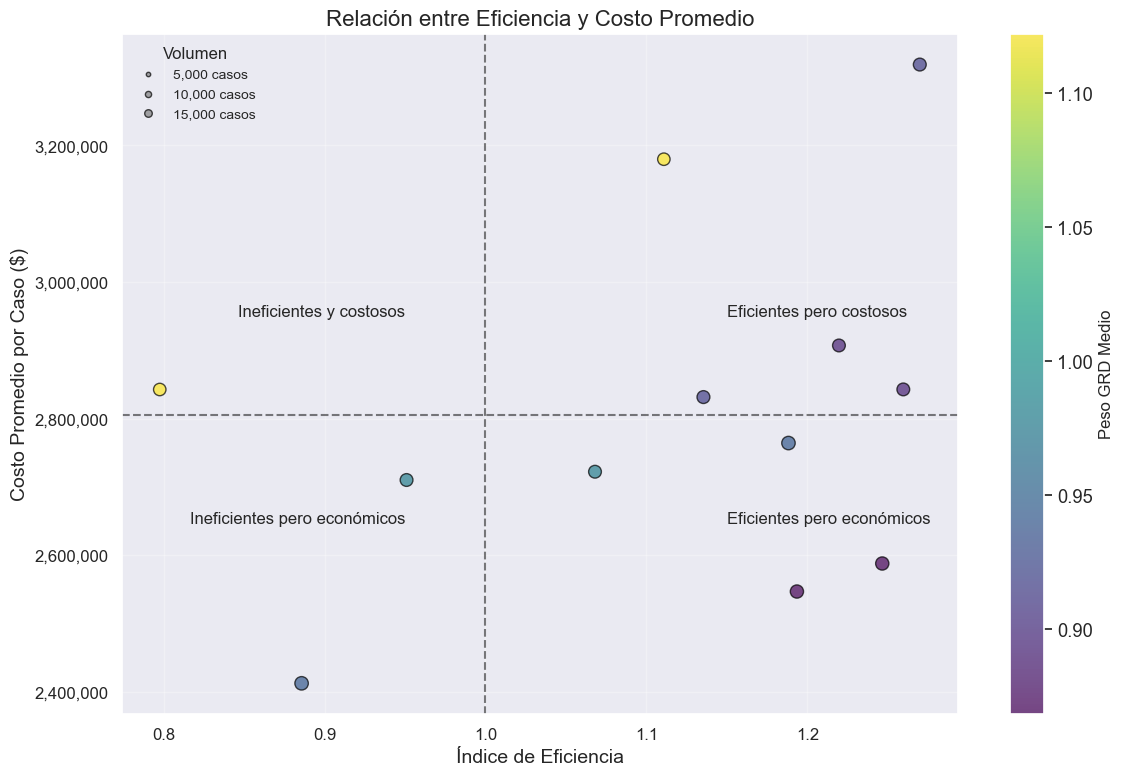

In [32]:
# Calculamos costo promedio por caso para cada hospital
for i, hospital in enumerate(hospitales):
    servicio = hospital['Servicio']
    datos_servicio = df_grd[df_grd['SERVICIO_SALUD'] == servicio]
    
    # Calculamos precio GRD promedio ponderado
    precio_grd_medio = np.average(datos_servicio['PRECIO_GRD_MEAN'], 
                                 weights=datos_servicio['CANTIDAD'])
    
    # Añadimos variabilidad según eficiencia
    # Hospitales eficientes tienden a tener costos menores
    factor_costo = 1.0 + (hospital['Indice_Eficiencia'] - 1) * 0.5 + np.random.uniform(-0.1, 0.1)
    costo_promedio = precio_grd_medio * factor_costo
    
    # Actualizamos el DataFrame
    df_hospitales.loc[i, 'Costo_Promedio'] = costo_promedio

# Visualizamos la relación entre eficiencia y costo
plt.figure(figsize=(12, 8))
scatter = plt.scatter(df_hospitales['Indice_Eficiencia'], df_hospitales['Costo_Promedio'], 
            c=df_hospitales['Peso_GRD_Medio'], cmap='viridis',
            s=df_hospitales['Casos']/500, alpha=0.7, edgecolor='black')

plt.title('Relación entre Eficiencia y Costo Promedio', fontsize=16)
plt.xlabel('Índice de Eficiencia', fontsize=14)
plt.ylabel('Costo Promedio por Caso ($)', fontsize=14)
plt.grid(alpha=0.3)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

# Formato para los números grandes
plt.gca().yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, p: format(int(x), ',')))

# Añadimos leyenda para el tamaño (casos)
sizes_legend = [5000, 10000, 15000]
for size in sizes_legend:
    plt.scatter([], [], s=size/500, c='gray', alpha=0.7, edgecolor='black',
                label=f'{size:,} casos')

# Añadimos colorbar para el peso GRD
cbar = plt.colorbar(scatter)
cbar.set_label('Peso GRD Medio', fontsize=12)

# Dividimos el gráfico en cuadrantes
plt.axvline(x=1, color='black', linestyle='--', alpha=0.5)
plt.axhline(y=df_hospitales['Costo_Promedio'].mean(), color='black', linestyle='--', alpha=0.5)

# Añadimos etiquetas a los cuadrantes
plt.text(0.95, df_hospitales['Costo_Promedio'].mean()*1.05, 
         "Ineficientes y costosos", ha='right', va='bottom', fontsize=12)
plt.text(1.15, df_hospitales['Costo_Promedio'].mean()*1.05, 
         "Eficientes pero costosos", ha='left', va='bottom', fontsize=12)
plt.text(0.95, df_hospitales['Costo_Promedio'].mean()*0.95, 
         "Ineficientes pero económicos", ha='right', va='top', fontsize=12)
plt.text(1.15, df_hospitales['Costo_Promedio'].mean()*0.95, 
         "Eficientes pero económicos", ha='left', va='top', fontsize=12)

plt.legend(fontsize=10, title='Volumen', title_fontsize=12)
plt.tight_layout()
plt.show()

Este gráfico de cuadrantes nos muestra la relación entre eficiencia (medida por el índice de eficiencia) y costo promedio por caso, considerando también el volumen de casos (tamaño de los círculos) y la complejidad (color).

Podemos identificar cuatro perfiles de hospitales:

1. **Eficientes y económicos** (cuadrante inferior izquierdo): Representan el ideal, con estancias más cortas que lo esperado y costos por debajo del promedio
2. **Eficientes pero costosos** (cuadrante inferior derecho): Tienen buena gestión de estancias pero sus costos son elevados, posiblemente por otros factores
3. **Ineficientes pero económicos** (cuadrante superior izquierdo): A pesar de estancias prolongadas, mantienen costos controlados
4. **Ineficientes y costosos** (cuadrante superior derecho): Representan el escenario más problemático, con oportunidades de mejora tanto en gestión de estancias como en control de costos

Este tipo de análisis es fundamental para:
- Identificar hospitales de referencia (benchmarking)
- Diseñar intervenciones específicas según el perfil de cada hospital
- Establecer incentivos apropiados en los mecanismos de pago
- Monitorear el impacto de cambios organizacionales o de política

## 5. Conclusiones

El análisis estadístico aplicado a datos GRD proporciona herramientas poderosas para:

1. **Entender patrones** de atención hospitalaria mediante estadística descriptiva
2. **Cuantificar la incertidumbre** a través de intervalos de confianza y pruebas de hipótesis
3. **Modelar relaciones** entre variables utilizando correlación y regresión
4. **Comparar eficiencia** entre hospitales mediante indicadores estandarizados
5. **Informar decisiones** de gestión y política sanitaria basadas en evidencia

Los Grupos Relacionados por Diagnóstico (GRD) se han convertido en una herramienta esencial para la gestión hospitalaria moderna, permitiendo comparaciones justas entre hospitales y facilitando mecanismos de financiamiento que incentivan la eficiencia y calidad.

En Chile, su implementación progresiva desde 2015 ha transformado la forma en que se financia la atención hospitalaria, pasando de mecanismos históricos o por prestación a un sistema basado en la complejidad real de los casos atendidos.

La combinación de ciencia de datos, estadística aplicada y conocimiento del contexto sanitario es fundamental para aprovechar al máximo el potencial de los GRD en la mejora continua del sistema de salud.

In [19]:
import pandas as pd

In [20]:
# Datos proporcionados
data = {
    "Nombre": [
        "CHRISTIAN ALEXANDER CALLE FIESTAS",
        "ALONSO ANTONIO CÁRDENAS PAZ",
        "DAVID ALEJANDRO HERNANDEZ URRUTIA",
        "IGNACIA VALENTINA HERRERA MUÑOZ",
        "KLAUS EZEQUIEL KRAUSE AVELLO",
        "BENJAMÍN IGNACIO PINTO FAÚNDEZ",
        "BENJAMÍN FERNANDO SÁNCHEZ TORRES",
        "MATÍAS IGNACIO SANDOVAL FILÚN",
        "ARIEL VAN KILSDONK MUNIZAGA",
        "FELIPE NICOLAS VAZQUEZ PROAÑO"
    ],
    "Identificador de inicio de sesión": [
        "ccallef@udd.cl",
        "a.cardenasp@udd.cl",
        "d.hernandezu@udd.cl",
        "i.herreram@udd.cl",
        "k.krausea@udd.cl",
        "b.pintof@udd.cl",
        "be.sanchezt@udd.cl",
        "m.sandovalf@udd.cl",
        "a.vankilsdonkm@udd.cl",
        "f.vazquezp@udd.cl"
    ],
    "Identificación del SIS": [
        "ccallef@udd.cl",
        "a.cardenasp@udd.cl",
        "d.hernandezu@udd.cl",
        "i.herreram@udd.cl",
        "k.krausea@udd.cl",
        "b.pintof@udd.cl",
        "be.sanchezt@udd.cl",
        "m.sandovalf@udd.cl",
        "a.vankilsdonkm@udd.cl",
        "f.vazquezp@udd.cl"
    ],
    "Sección": [
        "ANÁLISIS DE DATOS E INFERENCIA ESTADÍSTICA"] * 10,
    "Rol": ["Estudiante"] * 10,
    "Última actividad": [
        "1 de mar en 20:12",
        "3 de mar en 12:03",
        "3 de mar en 7:14",
        "3 de mar en 12:02",
        "3 de mar en 11:57",
        "3 de mar en 12:03",
        "3 de mar en 12:02",
        "",
        "3 de mar en 11:15",
        "3 de mar en 12:02"
    ],
    "Actividad total": [
        "",
        "47:44",
        "",
        "50:42",
        "35:08",
        "44:50",
        "47:31",
        "",
        "",
        "48:20"
    ]
}

# Crear DataFrame
df_estudiantes = pd.DataFrame(data)

# Mostrar DataFrame
df_estudiantes

,Nombre,Identificador de inicio de sesión,Identificación del SIS,Sección,Rol,Última actividad,Actividad total
0,CHRISTIAN ALEXANDER CALLE FIESTAS,ccallef@udd.cl,ccallef@udd.cl,ANÁLISIS DE DATOS E INFERENCIA ESTADÍSTICA,Estudiante,1 de mar en 20:12,
1,ALONSO ANTONIO CÁRDENAS PAZ,a.cardenasp@udd.cl,a.cardenasp@udd.cl,ANÁLISIS DE DATOS E INFERENCIA ESTADÍSTICA,Estudiante,3 de mar en 12:03,47:44
2,DAVID ALEJANDRO HERNANDEZ URRUTIA,d.hernandezu@udd.cl,d.hernandezu@udd.cl,ANÁLISIS DE DATOS E INFERENCIA ESTADÍSTICA,Estudiante,3 de mar en 7:14,
3,IGNACIA VALENTINA HERRERA MUÑOZ,i.herreram@udd.cl,i.herreram@udd.cl,ANÁLISIS DE DATOS E INFERENCIA ESTADÍSTICA,Estudiante,3 de mar en 12:02,50:42
4,KLAUS EZEQUIEL KRAUSE AVELLO,k.krausea@udd.cl,k.krausea@udd.cl,ANÁLISIS DE DATOS E INFERENCIA ESTADÍSTICA,Estudiante,3 de mar en 11:57,35:08
5,BENJAMÍN IGNACIO PINTO FAÚNDEZ,b.pintof@udd.cl,b.pintof@udd.cl,ANÁLISIS DE DATOS E INFERENCIA ESTADÍSTICA,Estudiante,3 de mar en 12:03,44:50
6,BENJAMÍN FERNANDO SÁNCHEZ TORRES,be.sanchezt@udd.cl,be.sanchezt@udd.cl,ANÁLISIS DE DATOS E INFERENCIA ESTADÍSTICA,Estudiante,3 de mar en 12:02,47:31
7,MATÍAS IGNACIO SANDOVAL FILÚN,m.sandovalf@udd.cl,m.sandovalf@udd.cl,ANÁLISIS DE DATOS E INFERENCIA ESTADÍSTICA,Estudiante,,
8,ARIEL VAN KILSDONK MUNIZAGA,a.vankilsdonkm@udd.cl,a.vankilsdonkm@udd.cl,ANÁLISIS DE DATOS E INFERENCIA ESTADÍSTICA,Estudiante,3 de mar en 11:15,
9,FELIPE NICOLAS VAZQUEZ PROAÑO,f.vazquezp@udd.cl,f.vazquezp@udd.cl,ANÁLISIS DE DATOS E INFERENCIA ESTADÍSTICA,Estudiante,3 de mar en 12:02,48:20


In [21]:
# Seleccionar un estudiante de forma aleatoria
estudiante_aleatorio = df_estudiantes.sample(n=1)
print(estudiante_aleatorio)


                        Nombre Identificador de inicio de sesión  \
1  ALONSO ANTONIO CÁRDENAS PAZ                a.cardenasp@udd.cl   

  Identificación del SIS                                     Sección  \
1     a.cardenasp@udd.cl  ANÁLISIS DE DATOS E INFERENCIA ESTADÍSTICA   

          Rol   Última actividad Actividad total  
1  Estudiante  3 de mar en 12:03           47:44  
